# Data Analyst Professional Practical Exam Submission

**You can use any tool that you want to do your analysis and create visualizations. Use this template to write up your summary for submission.**

You can use any markdown formatting you wish. If you are not familiar with Markdown, read the [Markdown Guide](https://s3.amazonaws.com/talent-assets.datacamp.com/Markdown+Guide.pdf) before you start.


## 📝 Task List

Your written report should include written text summaries and graphics of the following:
- Data validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Definition of a metric for the business to monitor  
  - How should the business use the metric to monitor the business problem
  - Can you estimate initial value(s) for the metric based on the current data
- Final summary including recommendations that the business should undertake

*Start writing report here..*

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation

First, I conducted a preliminary review of the dataset to assess its dimensions, schema, and data types against the provided data dictionary.

In [29]:
SELECT *
FROM 'DA_outbound_call_nursing_team.csv'



,patient_id,screening_type,screening_completed_ind,latest_call_date,reached_ind,screening_date
0,7.229306e+21,CBP,1.0,2024-09-12 00:00:00+00:00,0.0,2024-12-12 00:00:00+00:00
1,7.229306e+21,CBP,1.0,2024-09-12 00:00:00+00:00,0.0,2024-09-21 00:00:00+00:00
2,7.229306e+21,CBP,1.0,2024-09-12 00:00:00+00:00,0.0,2024-10-22 00:00:00+00:00
3,7.229306e+21,CBP,1.0,2024-09-12 00:00:00+00:00,0.0,2024-10-01 00:00:00+00:00
4,7.229306e+21,CBP,1.0,2024-09-12 00:00:00+00:00,0.0,2024-12-12 00:00:00+00:00
...,...,...,...,...,...,...
1983,8.932289e+21,BCS,0.0,2024-10-22 00:00:00+00:00,1.0,2024-11-10 00:00:00+00:00
1984,8.932289e+21,BCS,None,2024-10-22 00:00:00+00:00,1.0,NaT
1985,8.932289e+21,BCS,1.0,2024-10-22 00:00:00+00:00,1.0,2024-11-10 00:00:00+00:00
1986,8.748195e+21,EED,1.0,2024-08-17 00:00:00+00:00,1.0,2024-09-11 00:00:00+00:00


Next, I proceeded with data cleaning and validation, starting with the 'screening_type' column. According to the data dictionary, there should only be five valid screening types. However, I identified a single record labeled 'A1C'. Since this value was not defined in the project scope and represented only one entry, I decided to remove it to ensure data consistency.

In [30]:
SELECT screening_type, COUNT(*) as cantidad_por_screening
FROM 'DA_outbound_call_nursing_team.csv'
GROUP BY screening_type;


,screening_type,cantidad_por_screening
0,CBP,421
1,EED,339
2,COL,838
3,BCS,359
4,OMW,30
5,A1C,1


I applied a similar validation process to the 'screening_completed_ind' column, where I identified two irregularities. First, I found a single record entered as an integer '1' instead of the standard float '1.0'; I standardized this value to match the dataset's format. Second, I detected five records containing the value 's'. Since this violates the expected boolean schema (0 or 1)  and represents a negligible volume of data, I excluded these records.

In [31]:
SELECT screening_completed_ind, COUNT(*) as cantidad
FROM 'DA_outbound_call_nursing_team.csv'
GROUP BY screening_completed_ind;

,screening_completed_ind,cantidad
0,None,613
1,s,5
2,1,1
3,1.0,1120
4,0.0,249


In [32]:
SELECT *
FROM 'DA_outbound_call_nursing_team.csv'
WHERE screening_completed_ind = 's';

,patient_id,screening_type,screening_completed_ind,latest_call_date,reached_ind,screening_date
0,2.652813e+21,COL,s,2024-08-24 00:00:00+00:00,1.0,2024-09-10 00:00:00+00:00
1,1.335235e+21,CBP,s,2024-08-25 00:00:00+00:00,0.0,2024-10-27 00:00:00+00:00
2,6.046095e+21,COL,s,2024-01-01 00:00:00+00:00,1.0,2024-05-13 00:00:00+00:00
3,7.313654e+21,CBP,s,2024-09-22 00:00:00+00:00,0.0,2024-10-08 00:00:00+00:00
4,4.768731e+21,CBP,s,2024-01-09 00:00:00+00:00,0.0,2024-03-22 00:00:00+00:00


Finally, applying a similar validation approach to the 'reached_ind' column, I identified a record containing the text '1 and reached'. Although this violates the strict boolean format, the intent clearly indicated a successful contact. Therefore, I standardized this value to '1.0' to preserve the data point rather than discarding it.

In [33]:
SELECT reached_ind, COUNT(*) as cantidad
FROM 'DA_outbound_call_nursing_team.csv'
GROUP BY reached_ind;

,reached_ind,cantidad
0,None,248
1,0.0,562
2,1.0,1177
3,1 and reached,1


Finally, I verified the temporal consistency of the dataset. I confirmed that for all records, the 'screening_date' occurred after the 'latest_call_date', ensuring that the intervention (the call) logically preceded the outcome (the screening).

In [34]:
SELECT patient_id, screening_date, latest_call_date
FROM df
WHERE screening_date < latest_call_date 


,patient_id,screening_date,latest_call_date


I implemented the data cleaning and validation steps described above using the Python Pandas library.

In [35]:
# Cleaning the "reached_ind" column
# Correcting the "1 and reached" entry
df['reached_ind'] = df['reached_ind'].replace({
    '1 and reached': 1.0
})

# Dropping the record with the invalid screening type "A1C"
# (Correction: "Dropping" has double P)
df = df[df['screening_type'] != 'A1C']

# Excluding records with invalid value "s"
df = df[df['screening_completed_ind'] != 's']

# Display the first few rows to verify cleaning
df.head(50)

,patient_id,screening_type,screening_completed_ind,latest_call_date,reached_ind,screening_date
0,7.229306e+21,CBP,1.0,2024-09-12 00:00:00+00:00,0.0,2024-12-12 00:00:00+00:00
1,7.229306e+21,CBP,1.0,2024-09-12 00:00:00+00:00,0.0,2024-09-21 00:00:00+00:00
2,7.229306e+21,CBP,1.0,2024-09-12 00:00:00+00:00,0.0,2024-10-22 00:00:00+00:00
3,7.229306e+21,CBP,1.0,2024-09-12 00:00:00+00:00,0.0,2024-10-01 00:00:00+00:00
4,7.229306e+21,CBP,1.0,2024-09-12 00:00:00+00:00,0.0,2024-12-12 00:00:00+00:00
5,7.229306e+21,CBP,1.0,2024-09-12 00:00:00+00:00,0.0,2024-09-21 00:00:00+00:00
6,7.229306e+21,CBP,1.0,2024-09-12 00:00:00+00:00,0.0,2024-10-22 00:00:00+00:00
7,7.229306e+21,CBP,1.0,2024-09-12 00:00:00+00:00,0.0,2024-10-01 00:00:00+00:00
8,7.229306e+21,CBP,1.0,2024-09-12 00:00:00+00:00,0.0,2024-12-12 00:00:00+00:00
9,7.229306e+21,CBP,1.0,2024-09-12 00:00:00+00:00,0.0,2024-09-21 00:00:00+00:00


**How many patients were reached successfully?**
To answer this question, I counted the distinct 'patient_ids' where the 'reached_ind' value equals 1.0. Additionally, I compared this figure against the total number of patients called to calculate the overall contact success rate.

In [36]:
SELECT 
    -- 1. Total Patients called
    COUNT(DISTINCT CASE WHEN reached_ind IS NOT NULL THEN patient_id END) AS Patiends_called,

    -- 2. Total patients reached successfully
    COUNT(DISTINCT CASE WHEN reached_ind = 1 THEN patient_id END) AS Reached_successfully,

    -- 3. Percentaje of patients reached successfully
    ROUND((COUNT(DISTINCT CASE WHEN reached_ind = 1 THEN patient_id END) * 100.0) / 
    NULLIF(COUNT(DISTINCT CASE WHEN reached_ind IS NOT NULL THEN patient_id END), 0), 2) AS Reached_successfully_perc

FROM df; -- O el nombre de tu tabla real


,Patiends_called,Reached_successfully,Reached_successfully_perc
0,92,66,71.74


**Were there differences in compliance depending on how many screenings a patient was eligible for**
To answer this question, I grouped the patients by their unique 'patient_id' and counted how many screenings were assigned to each one. This revealed that patients fall into different groups depending on the quantity of screenings required.

In [37]:
SELECT patient_id, COUNT(screening_type) AS Screening_count, screening_completed_ind
FROM df
WHERE screening_type IS NOT NULL 
GROUP BY patient_id, screening_completed_ind              
ORDER BY Screening_count DESC

,patient_id,Screening_count,screening_completed_ind
0,7.582300e+21,64,1.0
1,7.229306e+21,64,1.0
2,8.180604e+21,64,1.0
3,9.554551e+21,63,1.0
4,1.732066e+21,48,None
...,...,...,...
262,6.945315e+21,1,None
263,6.342429e+21,1,1.0
264,7.426107e+21,1,None
265,8.837717e+21,1,1.0


Next, using Pandas and Seaborn, I calculated and visualized the completion rate based on the number of assigned screenings.

In [38]:
import pandas as pd

# Ensure the compliance column is numeric to allow calculation of the mean
df['screening_completed_ind'] = pd.to_numeric(df['screening_completed_ind'], errors='coerce')

# 1. Calculate the total screening load (count) per patient
df['num_screenings'] = df.groupby('patient_id')['screening_type'].transform('count')

# 2. Group by screening count and calculate the average compliance rate
result = df.groupby('num_screenings')['screening_completed_ind'].mean().reset_index()

# 3. Display the aggregated results
print(result)

   num_screenings  screening_completed_ind
0               1                 1.000000
1               7                 0.666667
2               8                 0.826990
3              26                 0.705882
4              27                 0.799443
5              63                 0.704000
6              64                 0.840607


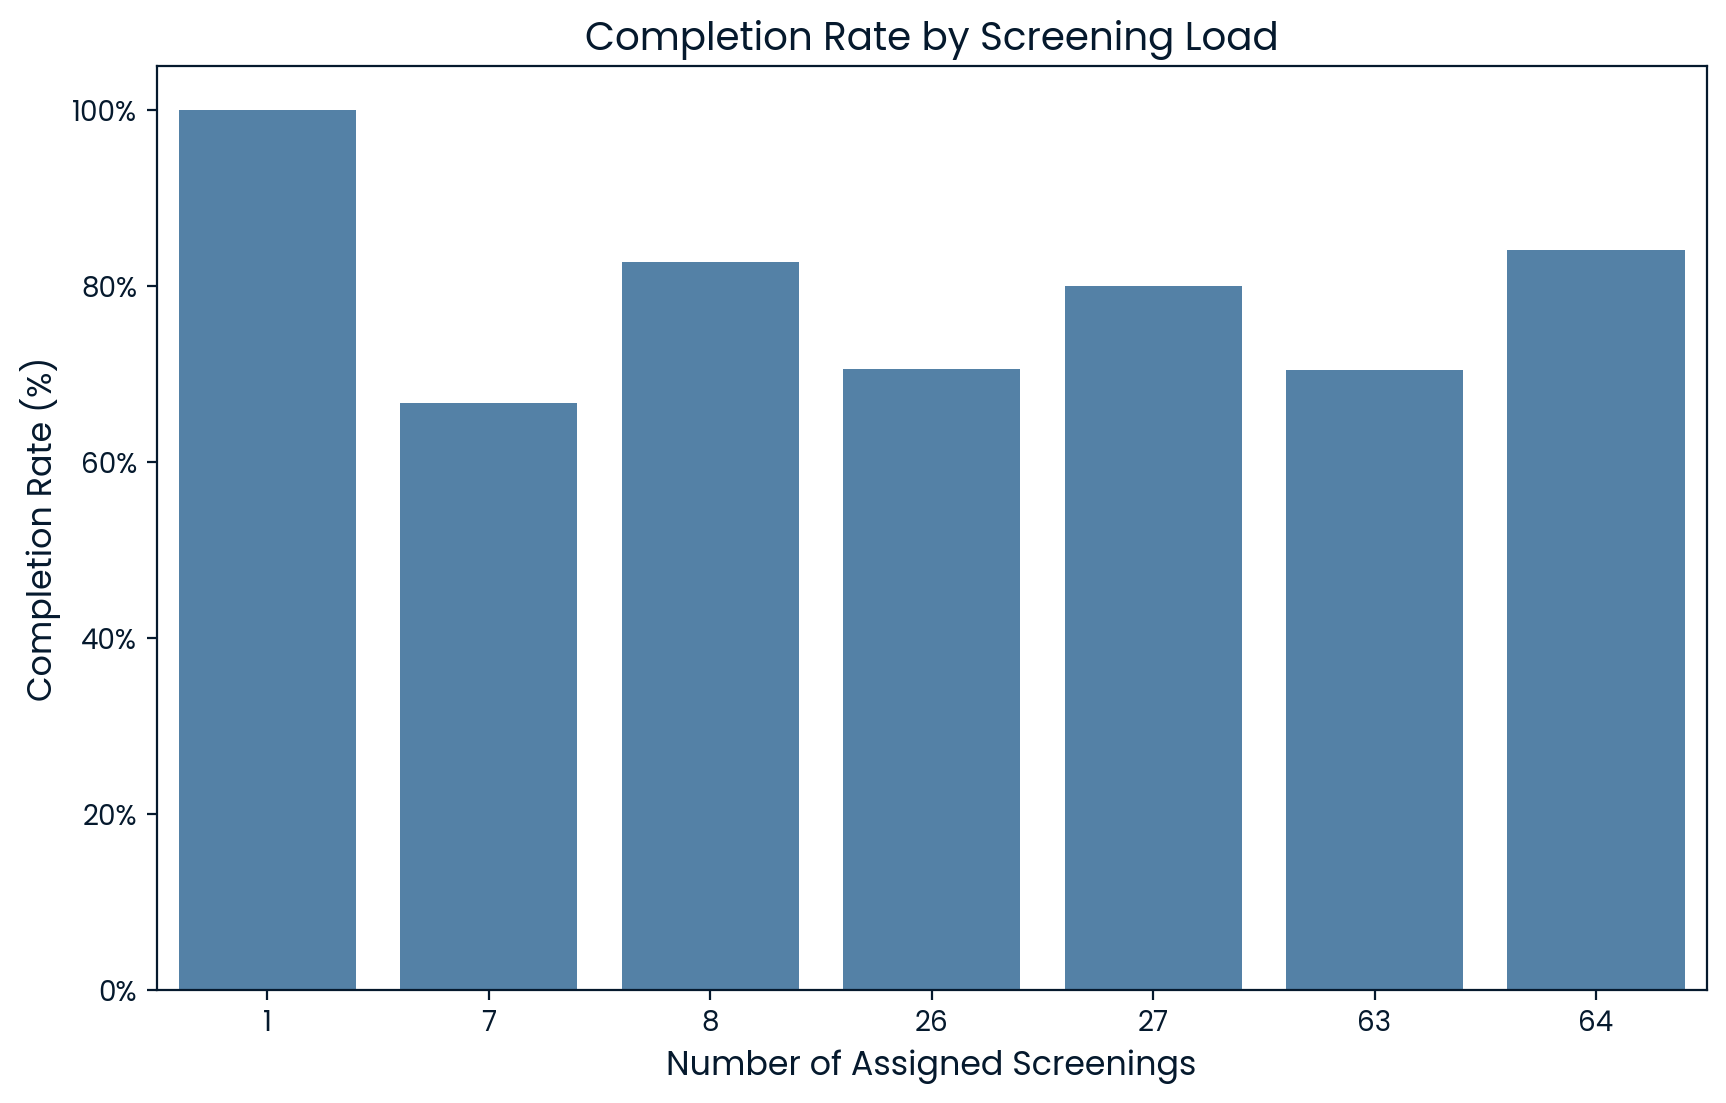

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick 

# Configure figure dimensions
plt.figure(figsize=(10, 6))

# Generate the Bar Plot
ax = sns.barplot(
    data=df, 
    x='num_screenings', 
    y='screening_completed_ind',
    color='steelblue',
    errorbar=None 
)

# Set chart labels and title
plt.title('Completion Rate by Screening Load', fontsize=14)
plt.xlabel('Number of Assigned Screenings', fontsize=12)
plt.ylabel('Completion Rate (%)', fontsize=12)

# Format Y-axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()

**Were patients more likely to get their screenings done (i.e. become compliant) after we reach them compared to patients we do not reach?**
To answer this question, I categorized the data into three distinct groups based on the call outcome: 'Contacted', 'Failed Attempt', and 'Never Called'. Subsequently, I calculated the compliance rate for each segment and visualized the comparison to assess the impact of the outreach efforts.

In [40]:
import pandas as pd

# Ensure numeric types for calculation
df['screening_completed_ind'] = pd.to_numeric(df['screening_completed_ind'], errors='coerce')
df['reached_ind'] = pd.to_numeric(df['reached_ind'], errors='coerce')

# Create a categorical column for Call Status
df['status_call'] = df['reached_ind'].fillna('Never called')
df['status_call'] = df['status_call'].replace({
    1.0: 'Contacted',
    0.0: 'Failed Attempt'
})

# 2. Calculate compliance rate by group (for verification)

impact_analysis = df.groupby('status_call')['screening_completed_ind'].mean() * 100

print(impact_analysis)

status_call
Contacted         79.844961
Failed Attempt    80.481928
Never called      93.333333
Name: screening_completed_ind, dtype: float64


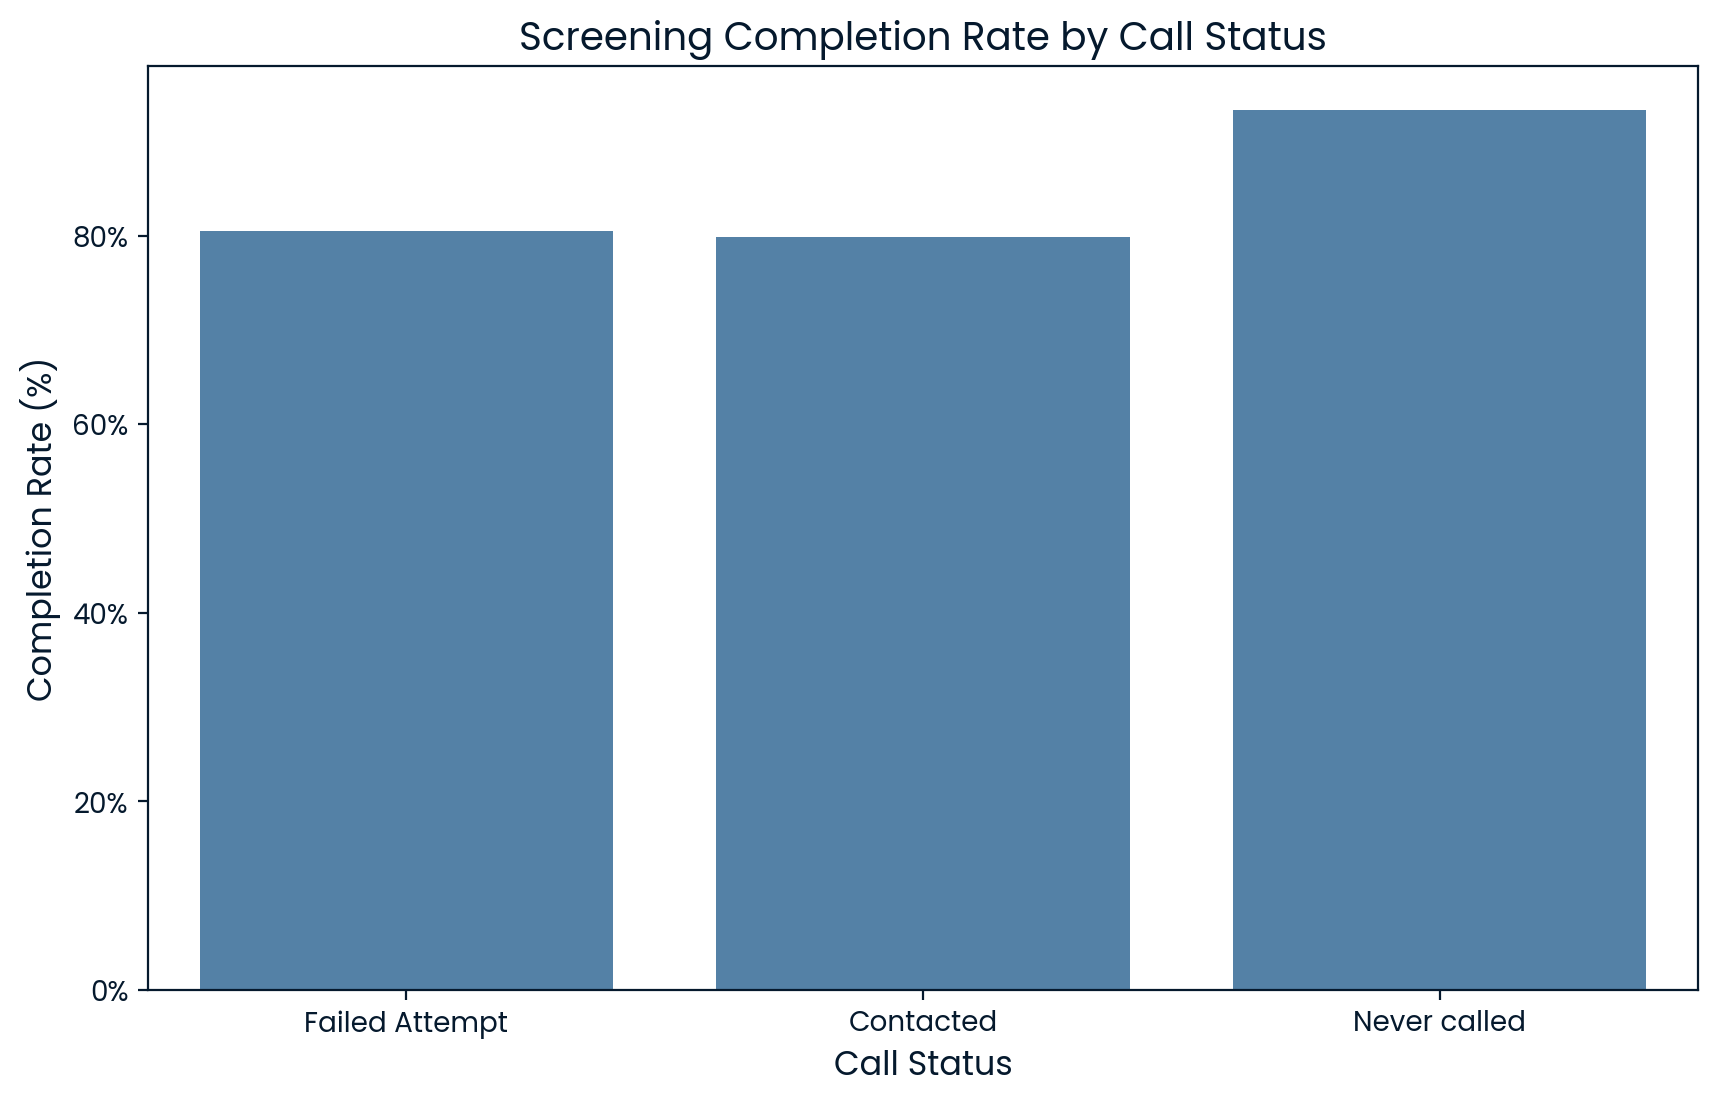

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick 

# Size of the report
plt.figure(figsize=(10, 6))

# GRAPHIC

ax = sns.barplot(
    data=df, 
    x='status_call', 
    y='screening_completed_ind',
    color='steelblue', 
    errorbar=None 
)

# Set chart labels and title
plt.title('Screening Completion Rate by Call Status', fontsize=14)
plt.xlabel('Call Status', fontsize=12)
plt.ylabel('Completion Rate (%)', fontsize=12)

# To percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()

**Supplemental Analysis: Compliance by Screening Type**
I extended the analysis by stratifying the completion rates by screening type. The goal was to ascertain whether specific screenings show significant variances in compliance when patients are contacted versus when they are not.

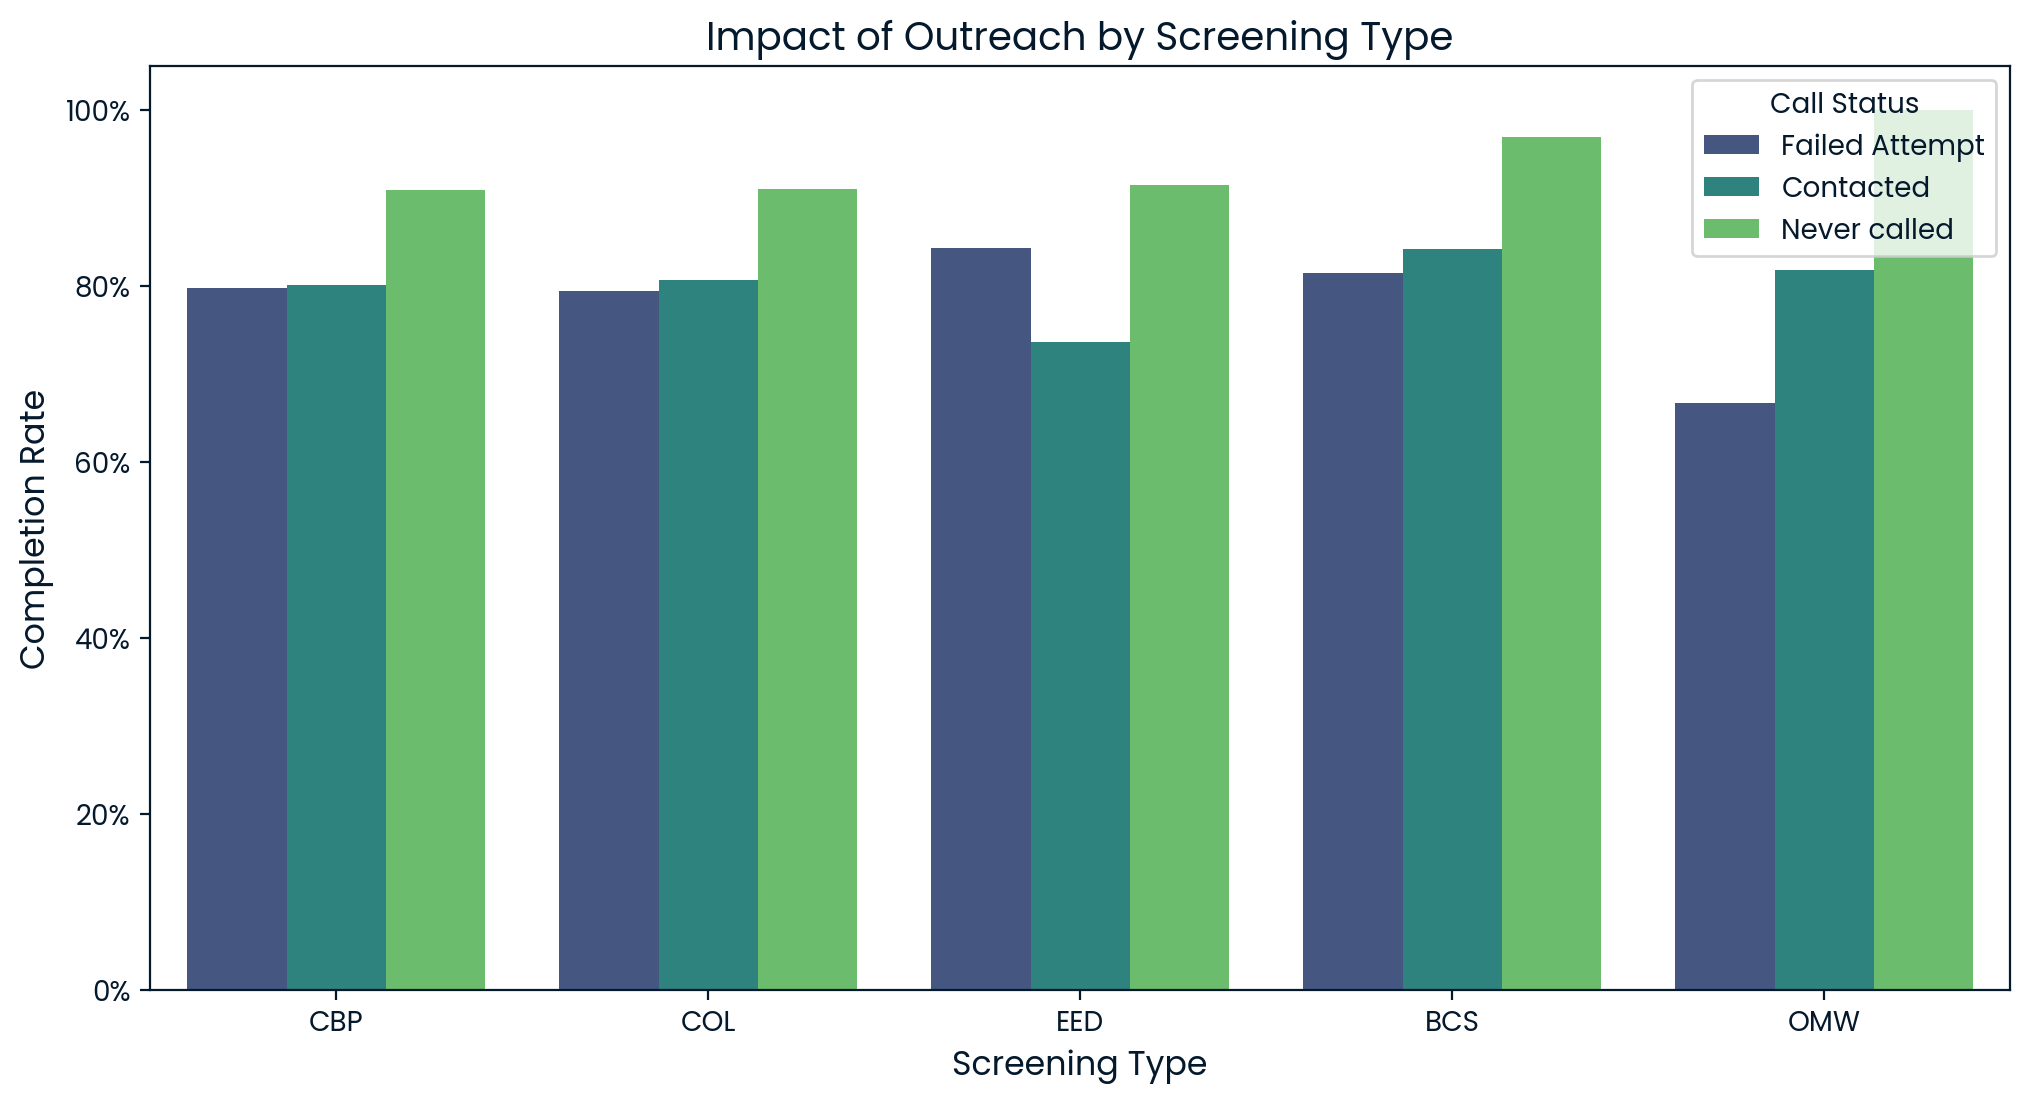

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Set figure dimensions
plt.figure(figsize=(12, 6))

# VISUALIZATION: Clustered Bar Chart
# X = Screening Type (BCS, COL, etc.)
# Y = Completion Rate
# Hue = Call Status (Contacted vs. Failed vs. Never Called)

ax = sns.barplot(
    data=df, 
    x='screening_type', 
    y='screening_completed_ind', 
    hue='status_call', # Must match the column created in the previous step
    palette='viridis', 
    errorbar=None
)

# Set chart labels and title in English
plt.title('Impact of Outreach by Screening Type', fontsize=14)
plt.ylabel('Completion Rate', fontsize=12)
plt.xlabel('Screening Type', fontsize=12)

# Format Y-axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Customize Legend Title
plt.legend(title='Call Status')

plt.show()

**Conclusions and recommendations**

**-Outreach Success:** Among the patients attempted, approximately 72% were successfully reached.
![patients reached succesfully](patients%20reached%20succesfully.png)

**-Screening Load:** Patients with a single assigned screening achieved a 100% completion rate. However, beyond this group, there is no significant correlation between the volume of assigned screenings (e.g., 7 vs. 64) and the likelihood of completion.
![completion rate by screening load](completion%20rate%20by%20screening%20load.png)

**-Impact of Calls (General):** Globally, the completion rate varies minimally (<1%) between successfully contacted patients and failed attempts. Interestingly, the "Never Called" group shows the highest compliance. This suggests that these patients likely had their exams scheduled during previous visits, rendering outreach unnecessary.

![screening completion rate by call status](screening%20completion%20rate%20by%20call%20status.png)

**-Impact by Screening Type:** While general outreach shows little impact on types like CBP, COL, and BCS, there are two notable exceptions:
    **EED (Early Elective Delivery):** Patients who were not successfully contacted showed higher compliance than those reached, suggesting calls might be ineffective for this demographic.
    **OMW (Osteoporosis):** This is the only category positively affected by calls. This may be attributed to the patient demographic (women over 50), who might be more receptive to phone communication.

![completion rate by screening type and calling status](completion%20rate%20by%20screening%20type%20and%20calling%20status.png)

**Recommendations:**

**Digital Alternatives:** I recommend diversifying contact channels based on the exam type and age demographics. Since OMW patients respond well to calls, resources should be focused there.

**Digital Alternatives:** For younger demographics or exams like EED where calls appear ineffective, testing alternative channels such as SMS reminders or email campaigns could improve engagement rates.